In [1]:
from sentence_transformers import SentenceTransformer

# Load the BGE-M3 model from HuggingFace on CPU
model = SentenceTransformer('BAAI/bge-m3', device='cpu')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [2]:
# Input sentences for inference
sentences = [
    "My soul died a long, long time ago. It rotted away in place for cowardice, and this body goes on to witness the scars of my cowardice punishment.",
    "The price of sin is amortized over time",
    "Time is the great equalizer in life",
    "Every saint has a past, every sinner has a future.",
    "Coke Zero is vastly better than coke diet.",
    "Bananas cost about 25 cents a pop"
]

# Generate dense embeddings
embeddings = model.encode(sentences, normalize_embeddings=True)

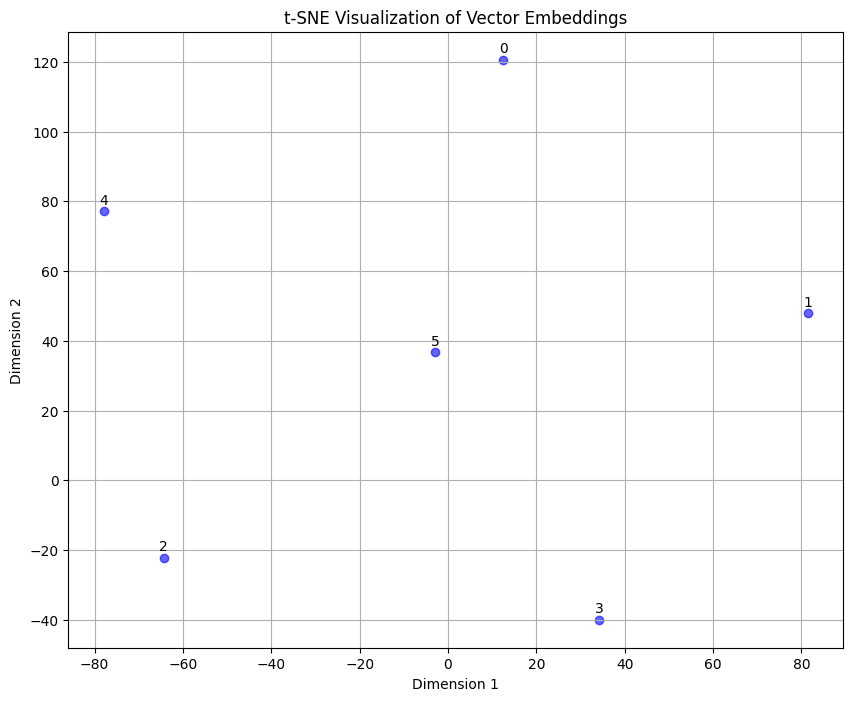

In [3]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming 'embeddings' is your array of 1024-size vectors
tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings) - 1), random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='blue', alpha=0.6)

for i, (x, y) in enumerate(reduced_embeddings):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(0, 5), ha='center')

plt.title("t-SNE Visualization of Vector Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()


In [4]:

import duckdb

# Connect to a DuckDB database (or use ':memory:' for transient storage)
con = duckdb.connect('vector_store.db')

# Install and load the Vector Similarity Search (vss) extension
con.execute("INSTALL vss;")
con.execute("LOAD vss;")

# Example: Create a table with a vector column (e.g., 1536 dimensions for OpenAI embeddings)
con.execute("""
CREATE TABLE IF NOT EXISTS embeddings (
    id VARCHAR,
    text TEXT,
    vec FLOAT[1024]
);
""")

In [6]:
def insert_embeddings(con, sentences, embeddings):
    con.execute("INSERT INTO embeddings (text, vec) SELECT * FROM (SELECT unnest(?) AS text, unnest(?) AS vec)", [sentences, embeddings])


In [9]:
insert_embeddings(con, sentences, embeddings)

In [53]:
class embed_ergonomics:
    """Optional docstring."""
    def __init__(self, parameter):
        self.attribute = parameter

    def vectorize(self):
        return(model.encode(self.attribute, normalize_embeddings=True))

In [54]:
item = embed_ergonomics("What good is a man without a soul?")

In [61]:
con.execute("""
    SELECT text
    FROM embeddings
    ORDER BY array_distance(vec, ?::FLOAT[1024]) ASC
    LIMIT 3;
""", [item.vectorize()]).fetchall()

[('My soul died a long, long time ago. It rotted away in place for cowardice, and this body goes on to witness the scars of my cowardice punishment.',),
 ('Every saint has a past, every sinner has a future.',),
 ('The price of sin is amortized over time',)]

In [58]:
item.vectorize()

array([-0.01754623, -0.00076623, -0.01351088, ..., -0.00975648,
       -0.04794936, -0.02050046], dtype=float32)

In [60]:
con.execute("CREATE OR REPLACE TABLE embeddings AS SELECT DISTINCT * FROM embeddings")
